# Statistical Analysis in Python (AI Generated)


## Data Loading and Exploration


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
df = pd.read_csv("../manual/brain_size.csv", sep=";", na_values=".")
print(f"Data loaded: {df.shape[0]} subjects, {df.shape[1]} columns")
df.head()


Data loaded: 40 subjects, 7 columns


,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,Female,133,132,124,118.0,64.5,816932.0
1,Male,140,150,124,NaN,72.5,1001121.0
2,Male,139,123,150,143.0,73.3,1038437.0
3,Male,133,129,128,172.0,68.8,965353.0
4,Female,137,132,134,147.0,65.0,951545.0


In [2]:
print("Summary statistics:")
df.describe()


Summary statistics:


,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
count,40.000000,40.000000,40.000000,36.000000,40.000000,3.700000e+01
mean,114.025000,113.075000,108.950000,148.750000,68.067500,8.991891e+05
std,19.711363,19.484889,19.682024,15.821098,2.620275,7.521862e+04
min,72.000000,71.000000,80.000000,118.000000,63.000000,7.875840e+05
25%,98.750000,96.750000,92.750000,137.500000,66.300000,8.453510e+05
50%,114.500000,113.000000,106.000000,147.000000,68.000000,8.989570e+05
75%,133.000000,129.000000,124.000000,159.000000,69.500000,9.450880e+05
max,141.000000,150.000000,150.000000,178.000000,73.500000,1.079549e+06


In [3]:
# Compare groups by gender
df.groupby("Gender").mean()


,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,
Female,111.652174,110.521739,106.565217,142.952381,66.634783,857349.000000
Male,117.235294,116.529412,112.176471,156.866667,70.005882,960554.533333


## Hypothesis Testing


In [4]:
# Test if VIQ mean differs from 0
t, p = stats.ttest_1samp(df["VIQ"].dropna(), 0)
print(f"One-sample t-test: t={t:.3f}, p={p:.4f}")


One-sample t-test: t=36.703, p=0.0000


In [5]:
# Compare VIQ between Female and Male
f_viq = df[df["Gender"]=="Female"]["VIQ"].dropna()
m_viq = df[df["Gender"]=="Male"]["VIQ"].dropna()
t, p = stats.ttest_ind(f_viq, m_viq)
print(f"Independent t-test: t={t:.3f}, p={p:.4f}")
print(f"  Female mean: {f_viq.mean():.1f}, Male mean: {m_viq.mean():.1f}")


Independent t-test: t=-0.963, p=0.3416
  Female mean: 110.5, Male mean: 116.5


In [6]:
# Paired test: FSIQ vs PIQ (same subjects)
t, p = stats.ttest_rel(df["FSIQ"], df["PIQ"])
print(f"Paired t-test: t={t:.3f}, p={p:.4f}")
w, p_w = stats.wilcoxon(df["FSIQ"], df["PIQ"])
print(f"Wilcoxon: W={w:.1f}, p={p_w:.4f}")


Paired t-test: t=3.383, p=0.0016
Wilcoxon: W=189.5, p=0.0030


## Linear Regression


In [7]:
# Does brain size predict PIQ?
sub = df.dropna(subset=["PIQ", "MRI_Count"])
res = stats.linregress(sub["MRI_Count"], sub["PIQ"])
print(f"Slope={res.slope:.4f}, Intercept={res.intercept:.2f}")
print(f"r={res.rvalue:.4f}, R-squared={res.rvalue**2:.4f}, p={res.pvalue:.4f}")


Slope=0.0001, Intercept=1.40
r=0.4549, R-squared=0.2069, p=0.0047


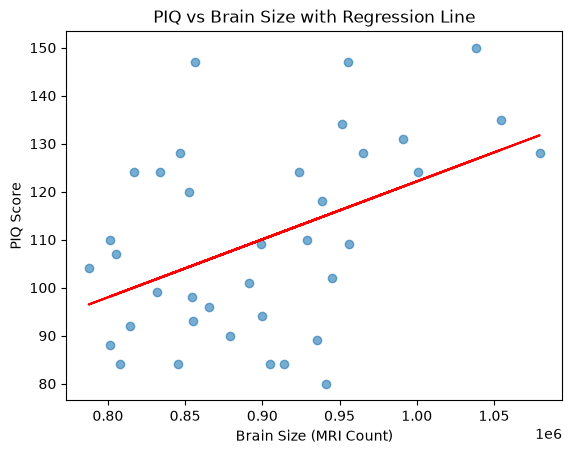

In [8]:
# Scatter plot with regression line
plt.scatter(sub["MRI_Count"], sub["PIQ"], alpha=0.6)
plt.plot(sub["MRI_Count"], res.slope * sub["MRI_Count"] + res.intercept, "r-")
plt.xlabel("Brain Size (MRI Count)")
plt.ylabel("PIQ Score")
plt.title("PIQ vs Brain Size with Regression Line")
plt.show()


## ANOVA on Iris Data


In [9]:
# Load iris data and test petal length across species
iris = pd.read_csv("../manual/iris.csv")
groups = [g["petal_length"].values for n, g in iris.groupby("species")]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.2f}, p={p_val:.2e}")


ANOVA: F=1180.16, p=2.86e-91


## Statistical Visualization


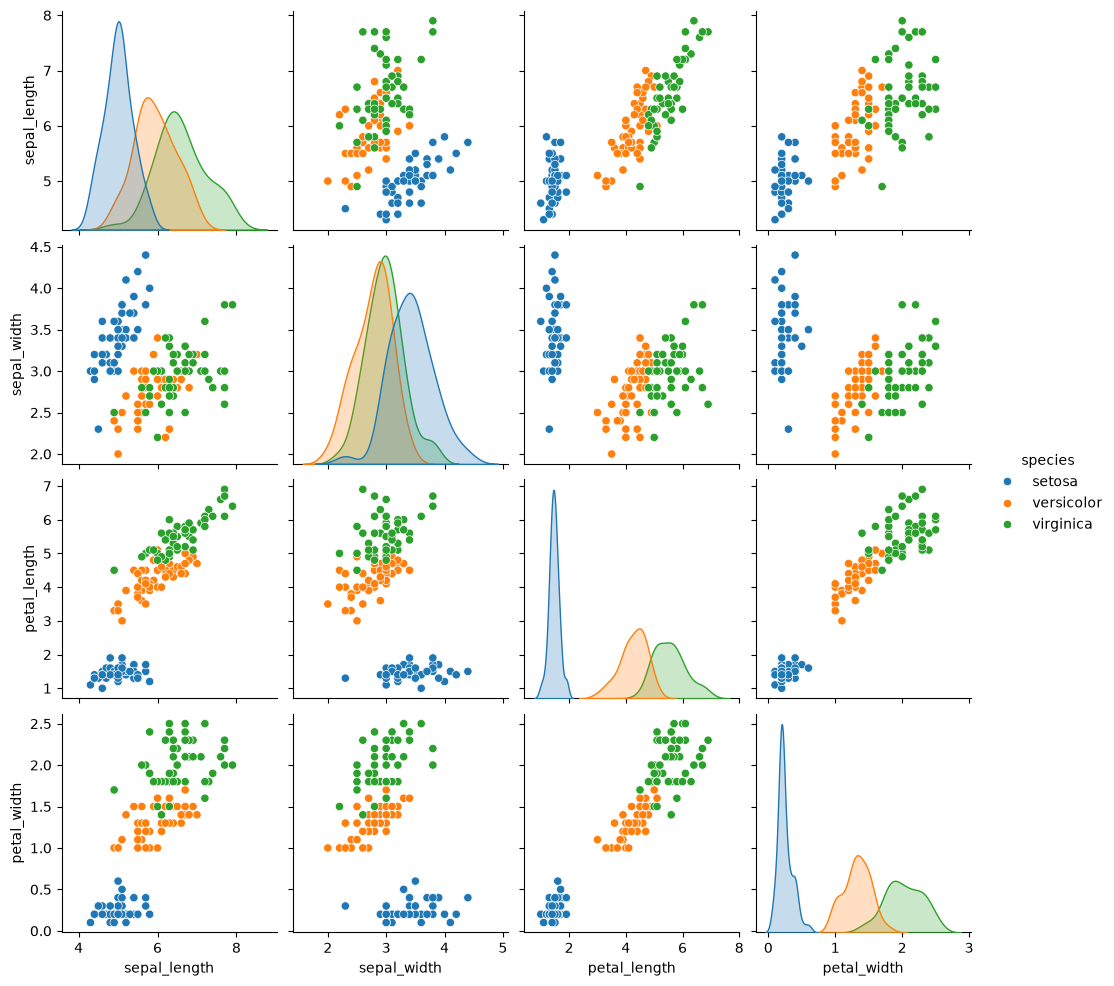

In [10]:
# Pairplot of iris variables colored by species
sns.pairplot(iris, hue="species", diag_kind="kde")
plt.show()


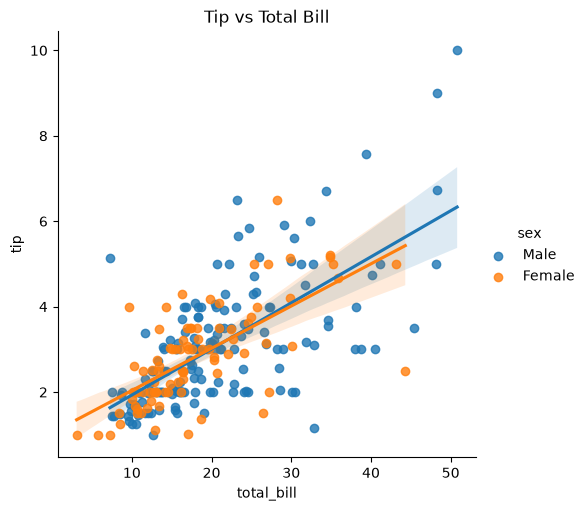

In [11]:
# Regression plot: tip vs total bill by gender
tips = sns.load_dataset("tips")
sns.lmplot(x="total_bill", y="tip", data=tips, hue="sex")
plt.title("Tip vs Total Bill")
plt.show()


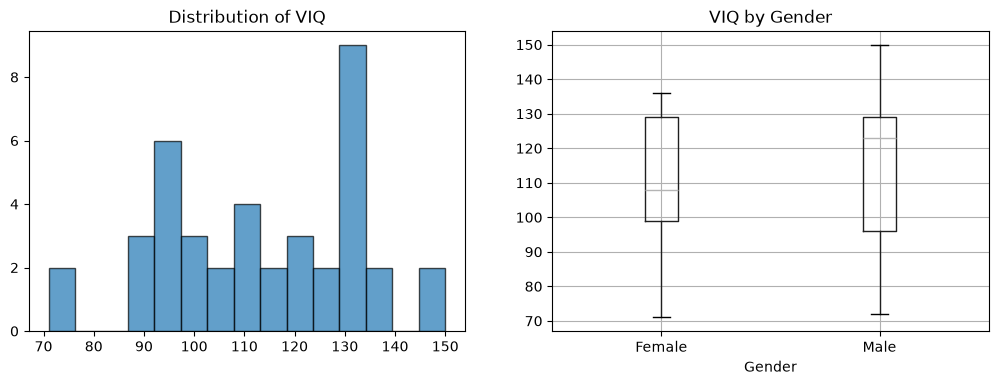

In [12]:
# Histogram of VIQ and boxplot by gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["VIQ"].dropna(), bins=15, edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of VIQ")
df.boxplot(column="VIQ", by="Gender", ax=axes[1])
axes[1].set_title("VIQ by Gender")
plt.suptitle("")
plt.show()


## Extension: Formulas with Statsmodels


In [13]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols("PIQ ~ MRI_Count + Gender", data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    PIQ   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     5.014
Date:                Fri, 24 Jul 2026   Prob (F-statistic):             0.0124
Time:                        13:27:24   Log-Likelihood:                -157.99
No. Observations:                  37   AIC:                             322.0
Df Residuals:                      34   BIC:                             326.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -27.6032     47.109     -0.